In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv(r"C:\Customer_Revenue_Intelligence\data\processed\online_retail_clean.csv",
                 parse_dates=['InvoiceDate'])

print(f"Clean dataset loaded: {len(df):,} rows, {df.shape[1]} columns")
print(f"Date range: {df['InvoiceDate'].min().date()} to {df['InvoiceDate'].max().date()}")
print(f"Unique customers: {df['Customer ID'].nunique():,}")

Clean dataset loaded: 779,407 rows, 9 columns
Date range: 2009-12-01 to 2011-12-09
Unique customers: 5,878


In [2]:
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')

cohort_df = df.groupby('Customer ID')['InvoiceMonth'].min().reset_index()
cohort_df.columns = ['Customer ID', 'CohortMonth']

df = df.merge(cohort_df, on='Customer ID', how='left')

df['CohortIndex'] = (df['InvoiceMonth'] - df['CohortMonth']).apply(lambda x: x.n)

print("Cohort columns created successfully")
print(f"\nSample — first 10 rows:")
print(df[['Customer ID', 'InvoiceMonth', 'CohortMonth', 'CohortIndex']].head(10).to_string())
print(f"\nCohort Index range: {df['CohortIndex'].min()} to {df['CohortIndex'].max()}")

Cohort columns created successfully

Sample — first 10 rows:
   Customer ID InvoiceMonth CohortMonth  CohortIndex
0        13085      2009-12     2009-12            0
1        13085      2009-12     2009-12            0
2        13085      2009-12     2009-12            0
3        13085      2009-12     2009-12            0
4        13085      2009-12     2009-12            0
5        13085      2009-12     2009-12            0
6        13085      2009-12     2009-12            0
7        13085      2009-12     2009-12            0
8        13085      2009-12     2009-12            0
9        13085      2009-12     2009-12            0

Cohort Index range: 0 to 24


In [3]:
cohort_data = df.groupby(['CohortMonth', 'CohortIndex'])['Customer ID'].nunique().reset_index()
cohort_data.columns = ['CohortMonth', 'CohortIndex', 'CustomerCount']

cohort_pivot = cohort_data.pivot_table(
    index='CohortMonth',
    columns='CohortIndex',
    values='CustomerCount'
)

cohort_size = cohort_pivot.iloc[:, 0]

retention_matrix = cohort_pivot.divide(cohort_size, axis=0).round(3)

print("Cohort retention matrix created successfully")
print(f"\nMatrix shape: {retention_matrix.shape}")
print(f"\nCohort sizes (customers acquired per month):")
print(cohort_size.to_string())

Cohort retention matrix created successfully

Matrix shape: (25, 25)

Cohort sizes (customers acquired per month):
CohortMonth
2009-12    955.0
2010-01    383.0
2010-02    374.0
2010-03    443.0
2010-04    294.0
2010-05    254.0
2010-06    270.0
2010-07    186.0
2010-08    162.0
2010-09    243.0
2010-10    377.0
2010-11    325.0
2010-12     76.0
2011-01     71.0
2011-02    124.0
2011-03    179.0
2011-04    106.0
2011-05    111.0
2011-06    108.0
2011-07    102.0
2011-08    106.0
2011-09    189.0
2011-10    221.0
2011-11    191.0
2011-12     28.0
Freq: M


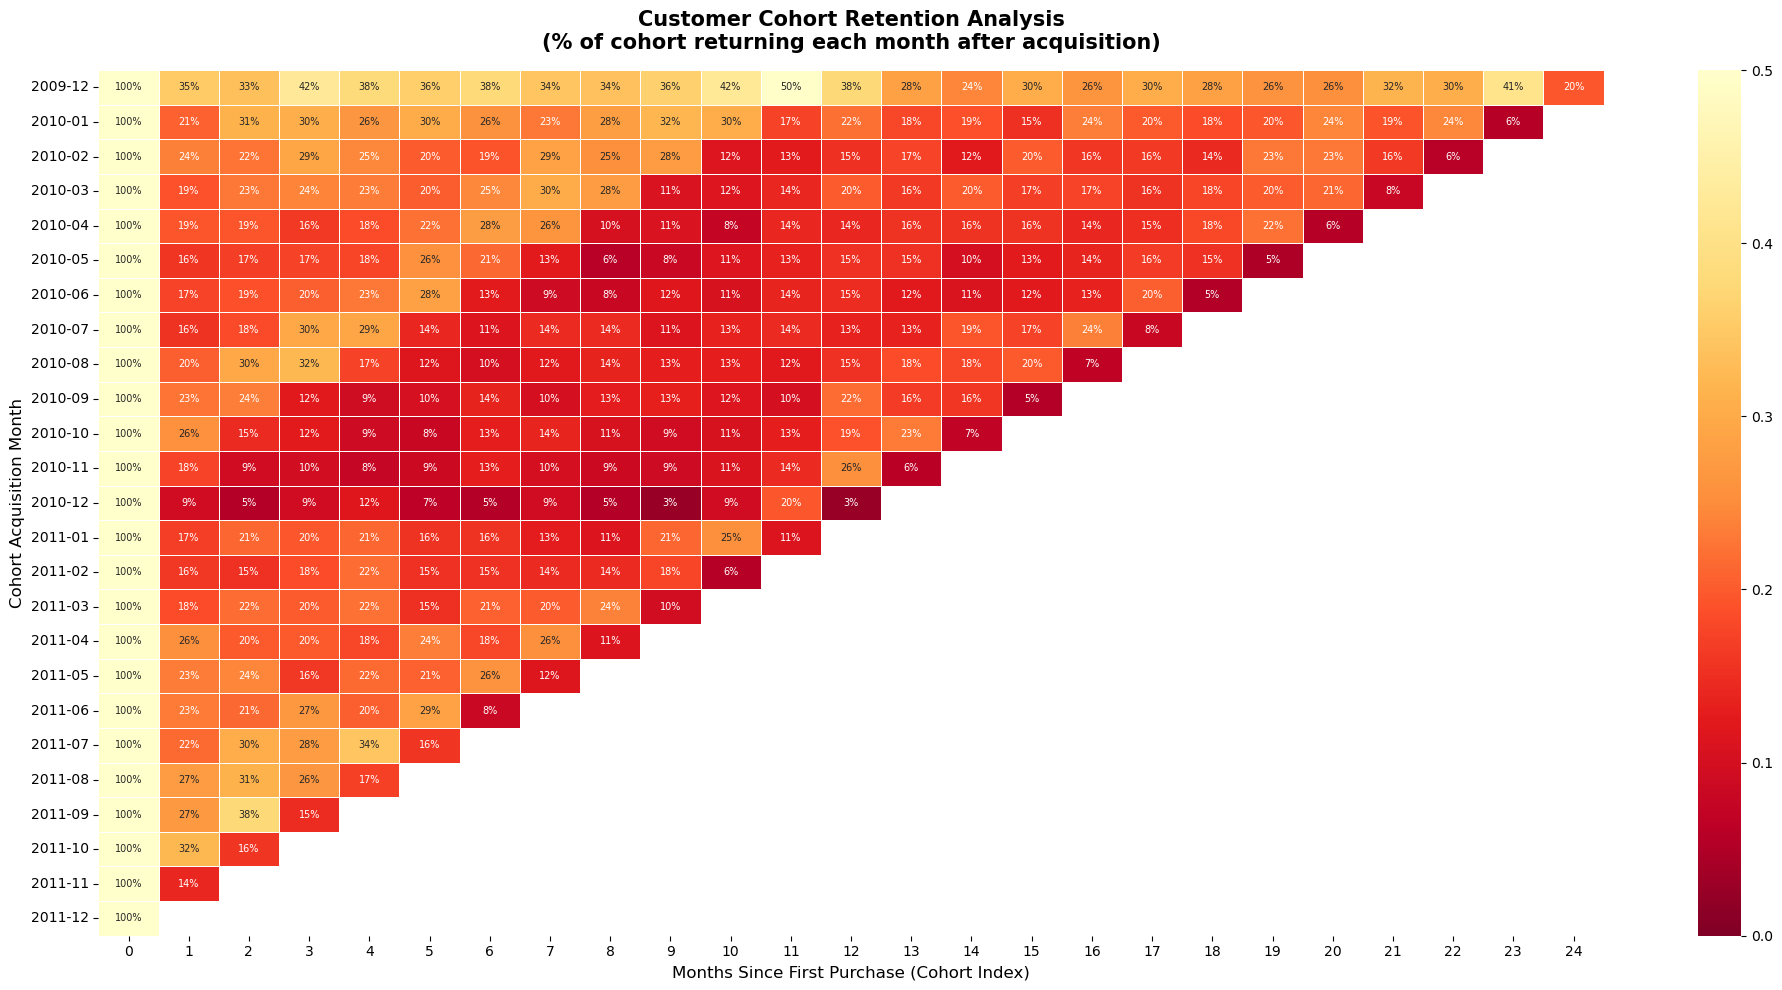

Cohort heatmap saved to reports/figures/


In [4]:
fig, ax = plt.subplots(figsize=(20, 10))

retention_display = retention_matrix.copy()
retention_display.index = retention_display.index.astype(str)

sns.heatmap(
    retention_display,
    annot=True,
    fmt='.0%',
    cmap='YlOrRd_r',
    ax=ax,
    vmin=0,
    vmax=0.5,
    linewidths=0.5,
    annot_kws={'size': 7}
)

ax.set_title('Customer Cohort Retention Analysis\n(% of cohort returning each month after acquisition)',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Months Since First Purchase (Cohort Index)', fontsize=12)
ax.set_ylabel('Cohort Acquisition Month', fontsize=12)

plt.tight_layout()
plt.savefig(r"C:\Customer_Revenue_Intelligence\reports\figures\cohort_retention_heatmap.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Cohort heatmap saved to reports/figures/")

In [5]:
print("=== COHORT RETENTION METRICS ===")

month1_retention = retention_matrix[1].dropna()
print(f"\nMonth 1 Retention Rates (% returning after first month):")
print(f"Average Month 1 retention: {month1_retention.mean()*100:.2f}%")
print(f"Best Month 1 retention:    {month1_retention.max()*100:.2f}% — Cohort: {month1_retention.idxmax()}")
print(f"Worst Month 1 retention:   {month1_retention.min()*100:.2f}% — Cohort: {month1_retention.idxmin()}")

print(f"\nMonth 3 Retention Rates:")
month3_retention = retention_matrix[3].dropna()
print(f"Average Month 3 retention: {month3_retention.mean()*100:.2f}%")

print(f"\nMonth 6 Retention Rates:")
month6_retention = retention_matrix[6].dropna()
print(f"Average Month 6 retention: {month6_retention.mean()*100:.2f}%")

print(f"\nMonth 12 Retention Rates:")
month12_retention = retention_matrix[12].dropna()
print(f"Average Month 12 retention: {month12_retention.mean()*100:.2f}%")

print(f"\nDec 2009 Cohort (largest — 955 customers) retention over time:")
dec_cohort = retention_matrix.loc['2009-12'].dropna()
for idx, val in dec_cohort.items():
    print(f"  Month {idx:>2}: {val*100:.1f}%")

=== COHORT RETENTION METRICS ===

Month 1 Retention Rates (% returning after first month):
Average Month 1 retention: 21.16%
Best Month 1 retention:    35.30% — Cohort: 2009-12
Worst Month 1 retention:   9.20% — Cohort: 2010-12

Month 3 Retention Rates:
Average Month 3 retention: 21.61%

Month 6 Retention Rates:
Average Month 6 retention: 17.83%

Month 12 Retention Rates:
Average Month 12 retention: 18.23%

Dec 2009 Cohort (largest — 955 customers) retention over time:
  Month  0: 100.0%
  Month  1: 35.3%
  Month  2: 33.4%
  Month  3: 42.5%
  Month  4: 38.0%
  Month  5: 35.9%
  Month  6: 37.7%
  Month  7: 34.2%
  Month  8: 33.6%
  Month  9: 36.2%
  Month 10: 42.2%
  Month 11: 49.5%
  Month 12: 37.6%
  Month 13: 28.3%
  Month 14: 24.4%
  Month 15: 30.3%
  Month 16: 26.3%
  Month 17: 30.3%
  Month 18: 28.3%
  Month 19: 26.0%
  Month 20: 25.5%
  Month 21: 31.5%
  Month 22: 30.5%
  Month 23: 40.7%
  Month 24: 19.7%


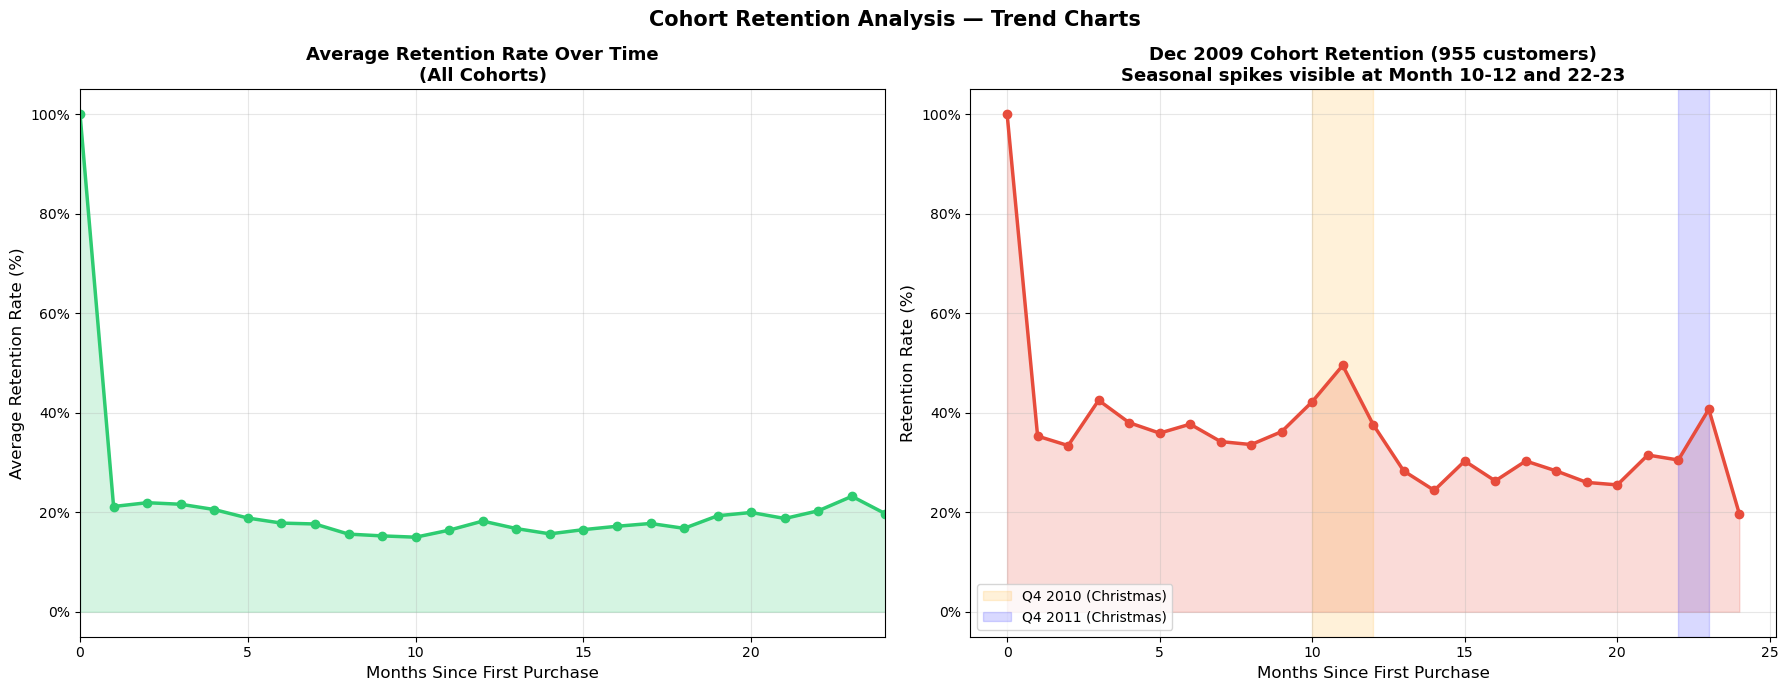

Retention trend chart saved to reports/figures/


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

avg_retention = retention_matrix.mean(axis=0) * 100
axes[0].plot(avg_retention.index, avg_retention.values,
             marker='o', linewidth=2.5, color='#2ecc71', markersize=6)
axes[0].fill_between(avg_retention.index, avg_retention.values, alpha=0.2, color='#2ecc71')
axes[0].set_xlabel('Months Since First Purchase', fontsize=12)
axes[0].set_ylabel('Average Retention Rate (%)', fontsize=12)
axes[0].set_title('Average Retention Rate Over Time\n(All Cohorts)', fontsize=13, fontweight='bold')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.0f}%'))
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, 24)

dec_cohort_pct = retention_matrix.loc['2009-12'] * 100
axes[1].plot(dec_cohort_pct.index, dec_cohort_pct.values,
             marker='o', linewidth=2.5, color='#e74c3c', markersize=6)
axes[1].fill_between(dec_cohort_pct.index, dec_cohort_pct.values, alpha=0.2, color='#e74c3c')
axes[1].set_xlabel('Months Since First Purchase', fontsize=12)
axes[1].set_ylabel('Retention Rate (%)', fontsize=12)
axes[1].set_title('Dec 2009 Cohort Retention (955 customers)\nSeasonal spikes visible at Month 10-12 and 22-23',
                  fontsize=13, fontweight='bold')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.0f}%'))
axes[1].grid(True, alpha=0.3)
axes[1].axvspan(10, 12, alpha=0.15, color='orange', label='Q4 2010 (Christmas)')
axes[1].axvspan(22, 23, alpha=0.15, color='blue', label='Q4 2011 (Christmas)')
axes[1].legend(fontsize=10)

plt.suptitle('Cohort Retention Analysis — Trend Charts', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(r"C:\Customer_Revenue_Intelligence\reports\figures\cohort_retention_trend.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Retention trend chart saved to reports/figures/")

In [7]:
print("=== COHORT ANALYSIS SUMMARY ===")
print(f"\nTotal cohorts tracked: {len(retention_matrix)}")
print(f"Total customers in cohort analysis: {int(cohort_size.sum()):,}")
print(f"\nAverage retention by month milestone:")
print(f"  Month 1:  {retention_matrix[1].mean()*100:.2f}%  — immediate return rate")
print(f"  Month 3:  {retention_matrix[3].mean()*100:.2f}%  — short term retention")
print(f"  Month 6:  {retention_matrix[6].mean()*100:.2f}%  — medium term retention")
print(f"  Month 12: {retention_matrix[12].mean()*100:.2f}% — long term retention")
print(f"\nKey findings:")
print(f"  Largest cohort: Dec 2009 — {int(cohort_size.max())} customers")
print(f"  Smallest cohort: Dec 2011 — {int(cohort_size.min())} customers")
print(f"  Best Month 1 retention: {retention_matrix[1].max()*100:.2f}% — {retention_matrix[1].idxmax()}")
print(f"  Worst Month 1 retention: {retention_matrix[1].min()*100:.2f}% — {retention_matrix[1].idxmin()}")
print(f"  Dec 2009 cohort peak retention: {retention_matrix.loc['2009-12'].max()*100:.2f}% at Month {retention_matrix.loc['2009-12'].idxmax()}")
print(f"\nBusiness insight:")
print(f"  ~79% of customers do NOT return after first purchase")
print(f"  Customers who do return show stable {retention_matrix.iloc[:,1:13].mean().mean()*100:.1f}% long-term retention")
print(f"  Clear Q4 seasonal spikes confirm Christmas-driven buying behaviour")

=== COHORT ANALYSIS SUMMARY ===

Total cohorts tracked: 25
Total customers in cohort analysis: 5,878

Average retention by month milestone:
  Month 1:  21.16%  — immediate return rate
  Month 3:  21.61%  — short term retention
  Month 6:  17.83%  — medium term retention
  Month 12: 18.23% — long term retention

Key findings:
  Largest cohort: Dec 2009 — 955 customers
  Smallest cohort: Dec 2011 — 28 customers
  Best Month 1 retention: 35.30% — 2009-12
  Worst Month 1 retention: 9.20% — 2010-12
  Dec 2009 cohort peak retention: 100.00% at Month 0

Business insight:
  ~79% of customers do NOT return after first purchase
  Customers who do return show stable 18.3% long-term retention
  Clear Q4 seasonal spikes confirm Christmas-driven buying behaviour
